## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Matthew Calvario

**Date:** 09/16/26

In [ ]:
# Your Phase 1 solution to the problem goes here.


1. What is the difference between regression and classification?

*Whereas Regression predicts continuous/numerical values, classification predicts discrete, categorical values. For example, a regression-based machine learning model may attempt predict the temperature in degrees given a few features in the dataset; by contrast, a classifier woul utilize the different features to determine if the temperature outside is **warm** or **cold**.*

2. What is a confusion table? What does it help us understand about a model's performance?

*A confusion table is a matrix-style tool that is used to measure how well a classification model is performing. Specifically, it compares the true values on the vertical axis and the predicted values on the horizontal axis by categorizing them into four distinct groups:*
- True Positive (TP): Model correctly predicts a positive/"Yes" response
- True Negative (TN): Model correctly predicts a negative/"No" response
- False Positive  (FP): Model incorrectly predicts a positive/"Yes" response when the true response is negative
- False Negative (FN): Model incorrectly predicts a negative/"No" response when the true response is positive.

*In the case of multiclass classification (more than two labels), the diagonal represents correct classifications, while off-diagonal cells show which classes are being confused with one another.*

*Thus, rather than simply measuring accuracy over the total predictions, the confusion table provides a more comprehensive view of the model's performance by revealing the specific types of errors it made.*


3. What does the SSE quantify about a particular model?

*The Sum of Squared Errors quantifies the total predication error of a given model by summing the squared differences between between the predicted values and the actual values across all observation.*


4. What are overfitting and underfitting?

*Overfitting is when a given model overlearns a dataset, matching not just the shape of the sample but the noise and minor fluctuations as well (for k-NN, the k-value is very small). Conversely, underfitting occurs when the model is too simple to capture the underlying pattern of the training data (for k-NN, this means the k-value is very large).*

5. Why does splitting the data into training and testing sets, and choosing  𝑘  by evaluating accuracy or SSE on the test set, improve model performance?

*The benefits of splitting data into training and testing sets is to ensure that the final classifier is not just memorizing the pattern of the data but actually provides insights that are replicable across the dataset. This is because training enables one to evalulate different values of k and compare their accuracy for classification or SSE; thus, you can better discriminate what values of k are generalizing well vs. overfitting/underfitting the pattern.*

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

*The biggest strength of using class labels is providing a simple evaluation framework (think the confusion table) alongside direct action; there is no additional/amgbigious interpretation of the final output other than "Yes or No." However, one loses some nuance when using these forms of hard predictions. For example, a prediction that says "Yes" after a 51% majority ruling is treated the same as a "Yes" with a 99% majority. Secondly, there is a risk of bias if the given dataset is greatly imbalanced; in other wrods, if one class dominates the other, the model will inadvertently lean towards predicting the majority class.*

*On the other hand, probability distributions in classification are very useful by quantifying this uncertainty, showing confidence levels to flag risky or ambiguous predictions. Furthermore, distributions allow one to adjust classification thresholds post-training more flexibly; That is, if one needed to add more weight towards false negatives than positives (due to their inherent cost in the context of its prediction), you are able to adjust precisely. That being said, using probability distributions can carry high computing costs by taking more memory, time, and processing power. This is because the eavluation is more complex, requiring specific probabilitistic metrics such as log loss or Brier scores. Additionally, classifying labels with this method requires additional calibration; in other words, the confidence score of the model does not always match its prediction of real-world values.*

Question 2.

1. Load the data. Perform some EDA, summarizing the target label and the features.

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

3. Build a  𝑘 -NN classifier. Explain how you select  𝑘.

4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [1]:
!git clone https://github.com/Matthew-Calvario/A03-knn.git



Cloning into 'A03-knn'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 6.85 KiB | 2.28 MiB/s, done.


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


(338, 4)

array([1, 2, 3, 4, 5])

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


,voltage,height,soil,mine_type
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5
337,0.314199,1.000000,1.0,5


,0
voltage,0
height,0
soil,0
mine_type,0


,0
voltage,0
height,0
soil,0
mine_type,0


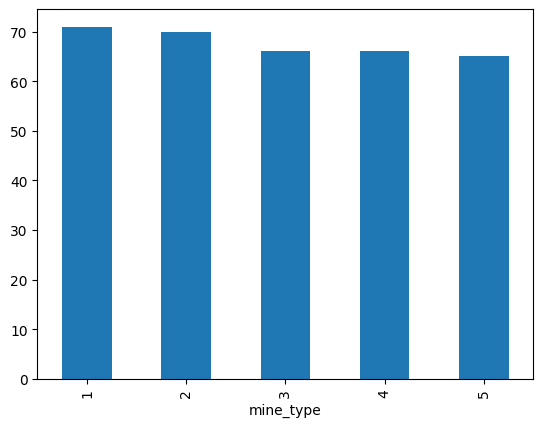

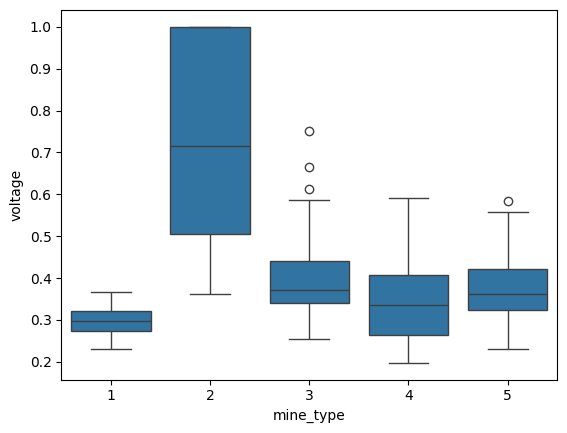

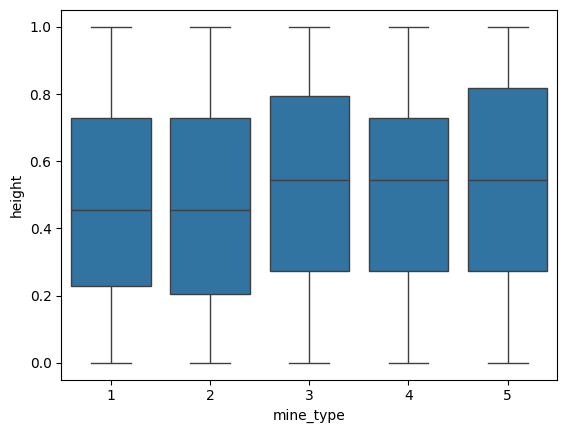

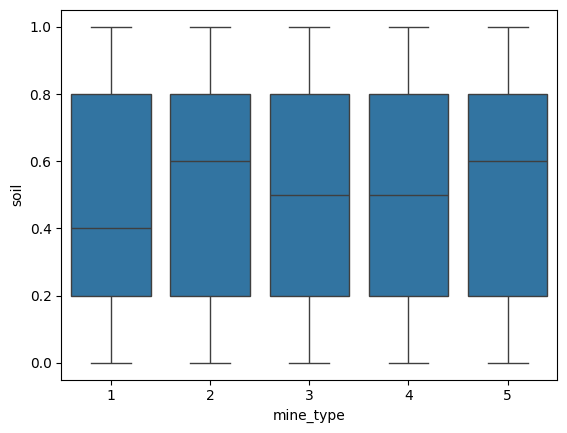

[(np.int64(1), 0.5088757396449705), (np.int64(2), 0.47337278106508873), (np.int64(3), 0.40828402366863903), (np.int64(4), 0.41420118343195267), (np.int64(5), 0.42011834319526625), (np.int64(6), 0.41420118343195267), (np.int64(7), 0.40236686390532544), (np.int64(8), 0.41420118343195267), (np.int64(9), 0.4319526627218935), (np.int64(10), 0.4319526627218935), (np.int64(11), 0.39644970414201186), (np.int64(12), 0.40828402366863903), (np.int64(13), 0.39644970414201186), (np.int64(14), 0.3905325443786982), (np.int64(15), 0.39644970414201186), (np.int64(16), 0.40236686390532544), (np.int64(17), 0.40236686390532544), (np.int64(18), 0.39644970414201186), (np.int64(19), 0.4260355029585799), (np.int64(20), 0.39644970414201186), (np.int64(21), 0.3905325443786982), (np.int64(22), 0.38461538461538464), (np.int64(23), 0.40236686390532544), (np.int64(24), 0.39644970414201186), (np.int64(25), 0.4319526627218935), (np.int64(26), 0.4437869822485207), (np.int64(27), 0.4260355029585799), (np.int64(28), 0.4

,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


In [65]:
# Question 2.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Q2.1 - EDA/Summary of Data

df = pd.read_csv("A03-knn/data/land_mines.csv")

display(df.describe())
display(df.shape)
display(df['mine_type'].unique())
display(df.head())
display(df.tail())

# Check for na/NULL values
display(df.isna().sum())

# Check for duplicated values
display(df.duplicated().sum())

# Look at distribution of mine_type; appears to be relatively even in distribution
df['mine_type'].value_counts().plot(kind='bar')
plt.show()

# Look at distribution of mine_type across variables
sns.boxplot(data=df, x='mine_type', y='voltage')
plt.show()
sns.boxplot(data=df, x='mine_type', y='height')
plt.show()
sns.boxplot(data=df, x='mine_type', y='soil')
plt.show()

print("""
SUMMARY

338 observations, Target = mine_type, Predictors/features = voltage, height,
and soil; no missing values.

The distribution for mine_type is relatively even across all 5 types and
338 samples. Thus, it will be easier to mitigate the potential for the model
to have bias toward a particular class of mine.

All of the features have similar scales, with ranges from 0 to 1, with the
exception of voltage, which has a minimum value of 0.197. This suggests that
the data has already been normalized, so there is less risk of one of the
features disproportionately impacting kNN distance calculations.

The boxplots show that voltage may have the strongest apparent relationship
with mine type. Whereas height and soil have minimal variation across the
mine types, voltage level has a distinct spike at Mine Type 2. While the other
mine types have similar distributions and levels of voltage, this feature
appears to have the most promise for providing discriminatory information
regarding mine type prediction.
""")


# Q2.2 - Creating Testing and Training split

X = df.drop(columns ='mine_type')
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Q2.3 - Choosing k

# Find best value of k by looping through a range
k_values = np.arange(1,31)

# Store accuracies of different k-values
test_accuracies = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X_train, y_train)

  y_pred = knn.predict(X_test)

  # Collect accuracy of the different k_values
  accuracy = accuracy_score(y_test, y_pred)
  test_accuracies.append((k, accuracy))

print(test_accuracies)
best_k, best_accuracy = max(test_accuracies, key=lambda x: x[1])

print("Best k:", best_k)
print(f"Best Accuracy: {best_accuracy:.2%}")

print("""
From the values 1-30 for k tested (for this split), k=1 yielded the highest
classification accuracy of the KNN models at 50.89%. Thus, for the final model,
I will use this value of k.

While very small values of k, like k=1, can be more sensitive to individual
observations, without a more robust validation approach (i.e. train-validate-test,
k-fold, etc.), k=1 is still the most appropriate choice because it produced the
highest accuracy on the provided validation set.
""")

# Final Model

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

# Q2.4 - Confusion Table
y_pred = knn.predict(X_test)

c_table = confusion_matrix(y_test, y_pred)
print(c_table)

# Make table into dataframe for legibility

c_table_df = pd.DataFrame(
    c_table,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Pred 1", "Pred 2", "Pred 3", "Pred 4", "Pred 5"]
)

display(c_table_df)

print("""
Based on the confusion table:

Overall Model Accuracy:
    (22 + 32 + 10 + 13 + 9) / 169
    = 0.5089
    = 50.89%

Most Accurate Class:
    Mine Type 2
    32 / 35 correct
    = 91.43%

Least Accurate Class:
    Mine Type 5
    9 / 32 correct
    = 28.13%
""")

# Q2.5 - Adiving future model user

print("""
If I were to provide someone this model, I would tell them to be highly cautious
of predictions for Mine Types 3, 4, and 5, if not completely discourage them
from using those predictions because of their sub-50% accuracy rates.

Even for Mine Type 1, I would warn them to be judicious about making a decision
since its probability of correctness is barely above the chances of a coin toss.

The only label prediction that I would trust for the person to consider with
confidence is the Type 2 Mine prediction, which correctly identifies about
91% of actual Type 2 mines.
""")



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]